In [74]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [75]:
!pip install typing

In [76]:
from langgraph.graph import StateGraph, END, START
import random
from typing import Dict, List,  TypedDict

In [77]:
class AgentState(TypedDict):
    guess:int
    counter: int
    actual_num:int

In [78]:
def setup(state:AgentState)->AgentState:
    state["actual_num"] = random.randint(0,10)
    state["counter"] = 0
    return state

def Guess(state:AgentState)->AgentState:
    state["guess"] = int(input("What do u think is the number?"))
    state["counter"] += 1
    return state

def should_continue(state:AgentState)->AgentState:
    if state["actual_num"] == state["guess"]:
        print(f"!!!YOU WON!!! The number is {state["actual_num"]}")
        return "EXIT"
    elif  state["counter"] <= 7:
        if state["actual_num"] > state["guess"]:
            print(f"The actual number is higher. \nEntering loop")
            return "LOOP"
        elif state["actual_num"] < state["guess"]:
            print("The actual number is lower. \nEntering loop")
            return "LOOP"
    else :
        print("EXIT")
        return "EXIT"

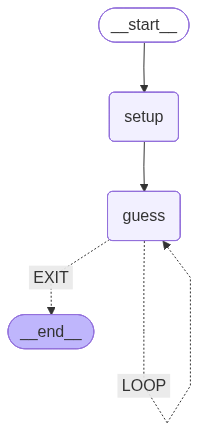

In [79]:
graph = StateGraph(AgentState)
graph.add_node("setup",setup)
graph.add_node("guess",Guess)
graph.add_edge(START,"setup")
graph.add_edge("setup","guess")


graph.add_conditional_edges(
    "guess",
    should_continue,
    {
        "EXIT":END,
        "LOOP":"guess"
    }
)
app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [80]:
app.invoke({})

What do u think is the number? 23


The actual number is lower. 
Entering loop , 1 < 5


What do u think is the number? 4


The actual number is higher. 
Entering loop , 2 < 5


What do u think is the number? 7


...

What do u think is the number? 5


The actual number is higher. 
Entering loop , 4 < 5


What do u think is the number? 6


!!!YOU WON!!! The number is 6


{'guess': 6, 'counter': 5, 'actual_num': 6}